# I. Initialization

# Executive Summary

**Objective**: Exploratory Data Analysis for Hospital Readmission Risk Prediction

**Key Findings**:
- 101,766 patients with 50 clinical features
- 11.2% 30-day readmission rate (primary target)
- Significant predictors: Length of stay, medication complexity, prior utilization
- Demographic disparities requiring fairness considerations
- Strong ROI potential: 10-20% reduction scenarios show positive returns

**Business Impact**: Clear intervention opportunities identified with quantified ROI projections

# Instructions for Running This EDA

**Prerequisites**: 
- Ensure data files are in `../data/` directory
- Required libraries: pandas, numpy, matplotlib, seaborn, scipy

**Execution Order**:
1. Run all cells in **Section I (Initialization)** first
2. Execute **Section II (Basic Analysis)** to understand dataset structure  
3. Continue sequentially through remaining sections
4. **Section VIII (Healthcare-Specific)** provides business-focused insights

**Expected Runtime**: ~5-10 minutes for complete execution

---

## 1. Initialize constants

In [1]:
DATA_PATH = "../data/diabetic_data.csv"
MAP_PATH = "../data/IDS_mapping.csv"

## 2. Import libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 3. Load Data

In [3]:
data = pd.read_csv(DATA_PATH)
data.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


## 4. Load Mapping Data

In [4]:
mapping = pd.read_csv(MAP_PATH)
mapping.head()

,admission_type_id,description
0,1,Emergency
1,2,Urgent
2,3,Elective
3,4,Newborn
4,5,Not Available


# II. Basic Analysis

## 1. Dataset Overview

In [5]:
print("Dataset Shape:", data.shape)
print("\nColumn Names:")
print(data.columns.tolist())
print("\nData Types:")
print(data.dtypes.value_counts())
print("\nBasic Information:")
data.info()

Dataset Shape: (101766, 50)

Column Names:
['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']

Data Types:
object    37
int64     13
Name: count, dtype: int64

Basic Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017

## 2. Missing Values Analysis

In [6]:
# Check for missing values
missing_values = data.isnull().sum()
missing_percentage = (missing_values / len(data)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percentage
}).sort_values('Missing Count', ascending=False)

print("Missing Values Summary:")
print(missing_df[missing_df['Missing Count'] > 0])

# Check for '?' values which are often used as missing indicators
question_mark_cols = []
for col in data.columns:
    if data[col].dtype == 'object':
        question_marks = (data[col] == '?').sum()
        if question_marks > 0:
            question_mark_cols.append((col, question_marks, (question_marks/len(data))*100))

if question_mark_cols:
    print("\n\nColumns with '?' values (potential missing data):")
    for col, count, pct in question_mark_cols:
        print(f"{col}: {count} ({pct:.2f}%)")

Missing Values Summary:
               Missing Count  Missing Percentage
max_glu_serum          96420           94.746772
A1Cresult              84748           83.277322


Columns with '?' values (potential missing data):
race: 2273 (2.23%)
weight: 98569 (96.86%)
payer_code: 40256 (39.56%)
medical_specialty: 49949 (49.08%)
diag_1: 21 (0.02%)
diag_2: 358 (0.35%)
diag_3: 1423 (1.40%)


## 3. Target Variable Analysis

Target Variable Distribution:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

Target Variable Percentages:
readmitted
NO     53.911916
>30    34.928169
<30    11.159916
Name: proportion, dtype: float64


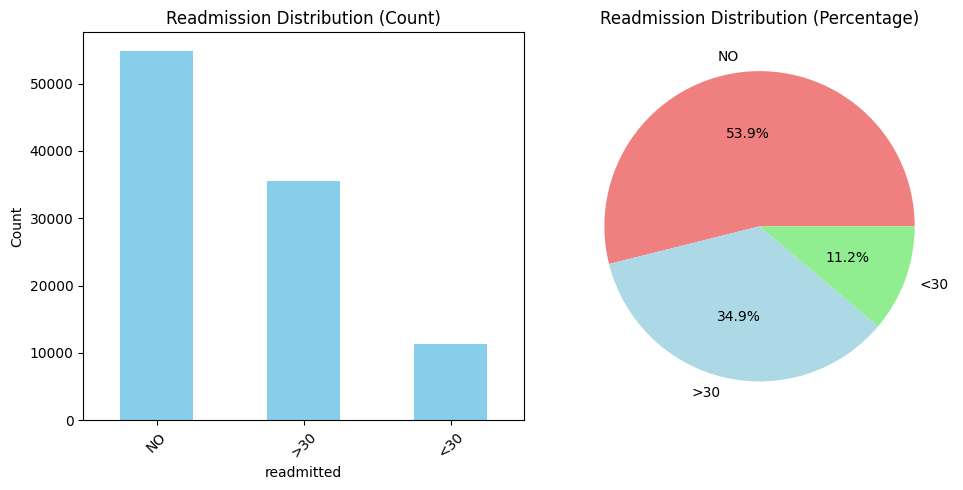

In [7]:
# Analyze the target variable (readmitted)
print("Target Variable Distribution:")
target_counts = data['readmitted'].value_counts()
print(target_counts)
print("\nTarget Variable Percentages:")
print(data['readmitted'].value_counts(normalize=True) * 100)

# Visualize target distribution
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
data['readmitted'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Readmission Distribution (Count)')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
data['readmitted'].value_counts(normalize=True).plot(kind='pie', autopct='%1.1f%%', colors=['lightcoral', 'lightblue', 'lightgreen'])
plt.title('Readmission Distribution (Percentage)')
plt.ylabel('')

plt.tight_layout()
plt.show()

# III. Numerical Features Analysis

## 1. Identify Numerical Columns

In [8]:
# Identify numerical columns
numerical_cols = data.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numerical columns ({len(numerical_cols)}):")
print(numerical_cols)

# Get basic statistics for numerical columns
print("\nDescriptive Statistics for Numerical Features:")
print(data[numerical_cols].describe())

Numerical columns (13):
['encounter_id', 'patient_nbr', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']

Descriptive Statistics for Numerical Features:
       encounter_id   patient_nbr  admission_type_id  \
count  1.017660e+05  1.017660e+05      101766.000000   
mean   1.652016e+08  5.433040e+07           2.024006   
std    1.026403e+08  3.869636e+07           1.445403   
min    1.252200e+04  1.350000e+02           1.000000   
25%    8.496119e+07  2.341322e+07           1.000000   
50%    1.523890e+08  4.550514e+07           1.000000   
75%    2.302709e+08  8.754595e+07           3.000000   
max    4.438672e+08  1.895026e+08           8.000000   

       discharge_disposition_id  admission_source_id  time_in_hospital  \
count             101766.000000        101766.000000     101766.000000   
mean       

## 2. Distribution of Numerical Features

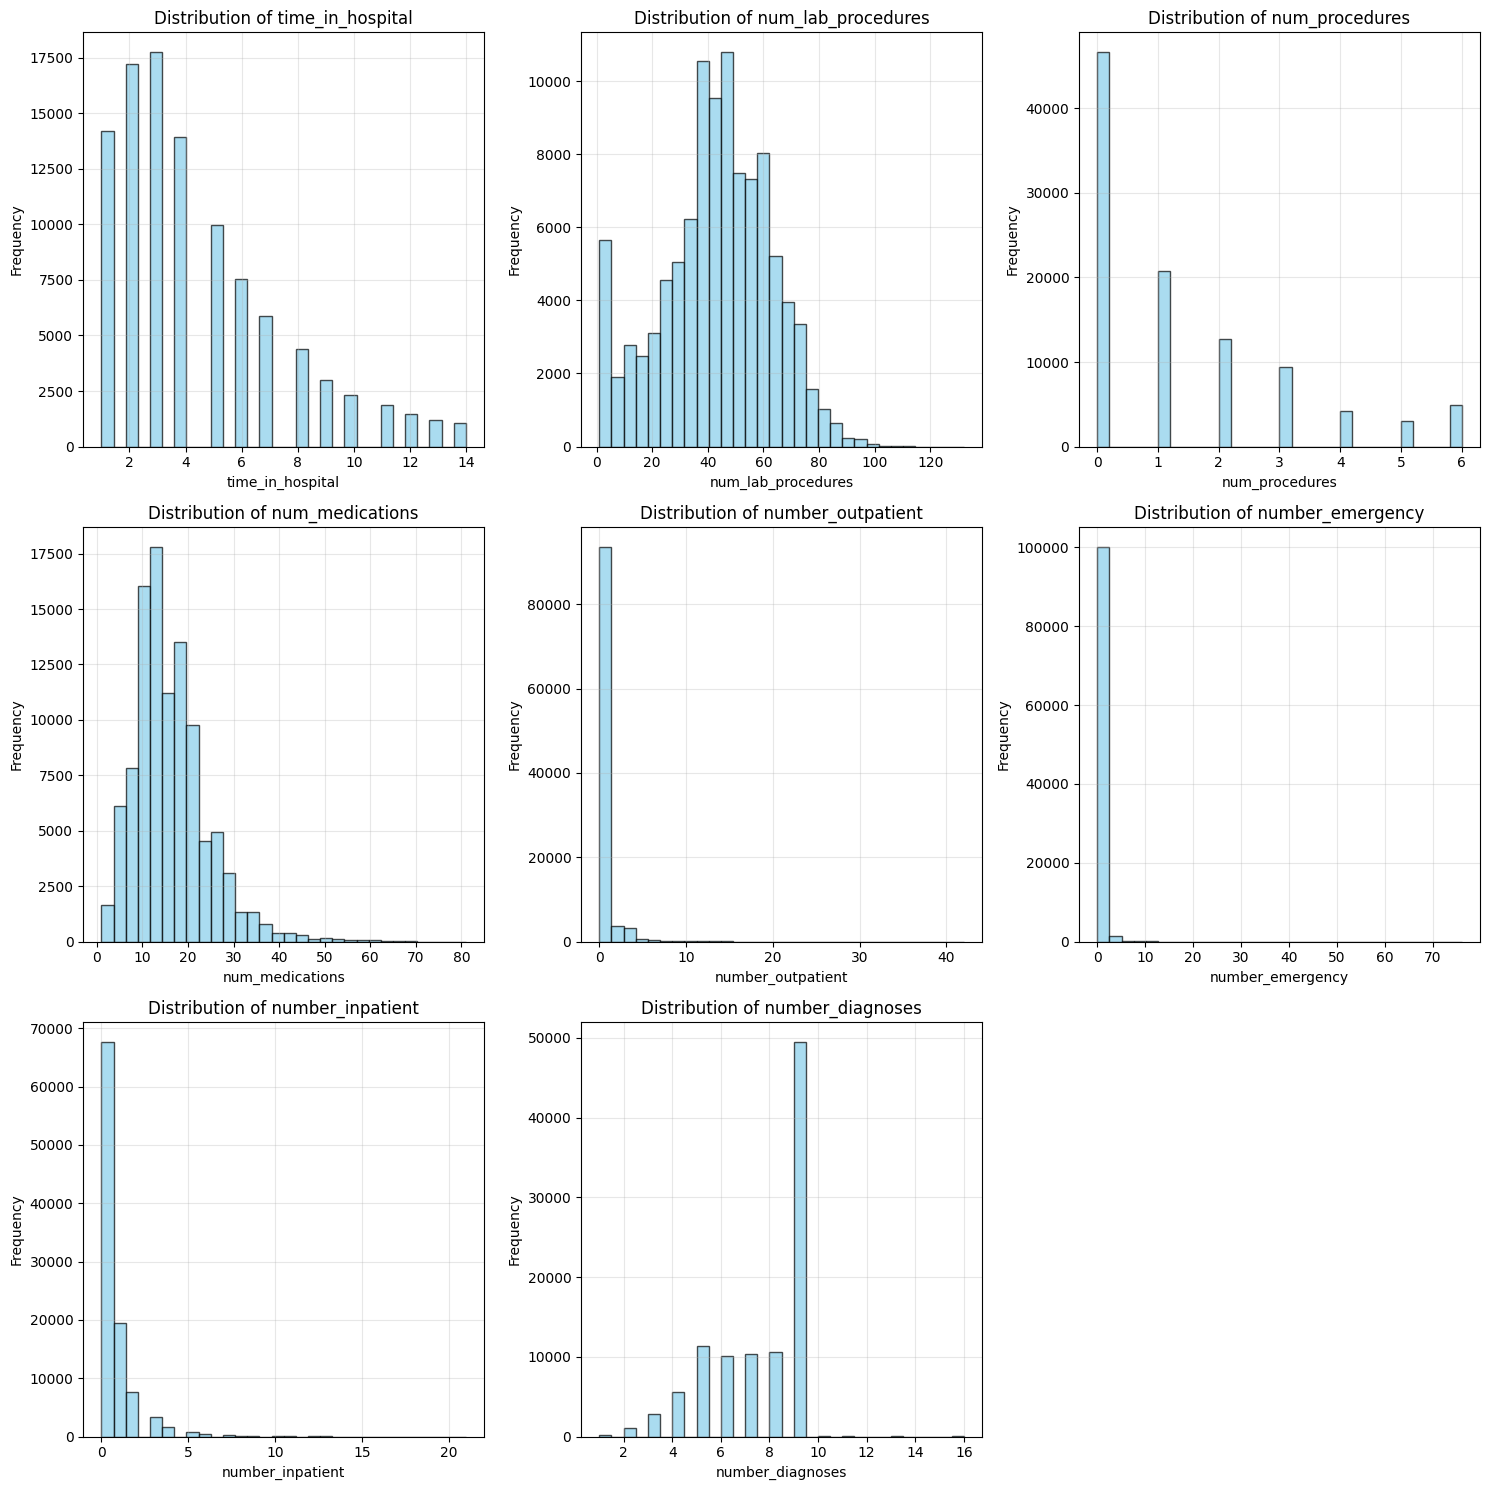

In [9]:
# Plot distributions of key numerical features
key_numerical_features = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 
                         'num_medications', 'number_outpatient', 'number_emergency', 
                         'number_inpatient', 'number_diagnoses']

# Filter to only include columns that exist in the dataset
existing_features = [col for col in key_numerical_features if col in data.columns]

if existing_features:
    n_cols = 3
    n_rows = (len(existing_features) + n_cols - 1) // n_cols
    
    plt.figure(figsize=(15, 5 * n_rows))
    
    for i, feature in enumerate(existing_features, 1):
        plt.subplot(n_rows, n_cols, i)
        data[feature].hist(bins=30, alpha=0.7, color='skyblue', edgecolor='black')
        plt.title(f'Distribution of {feature}')
        plt.xlabel(feature)
        plt.ylabel('Frequency')
        plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("Key numerical features not found in the dataset. Let's check all numerical columns:")
    if numerical_cols:
        n_cols = 3
        n_rows = (len(numerical_cols) + n_cols - 1) // n_cols
        
        plt.figure(figsize=(15, 5 * n_rows))
        
        for i, feature in enumerate(numerical_cols, 1):
            plt.subplot(n_rows, n_cols, i)
            data[feature].hist(bins=30, alpha=0.7, color='skyblue', edgecolor='black')
            plt.title(f'Distribution of {feature}')
            plt.xlabel(feature)
            plt.ylabel('Frequency')
            plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

## 3. Correlation Analysis

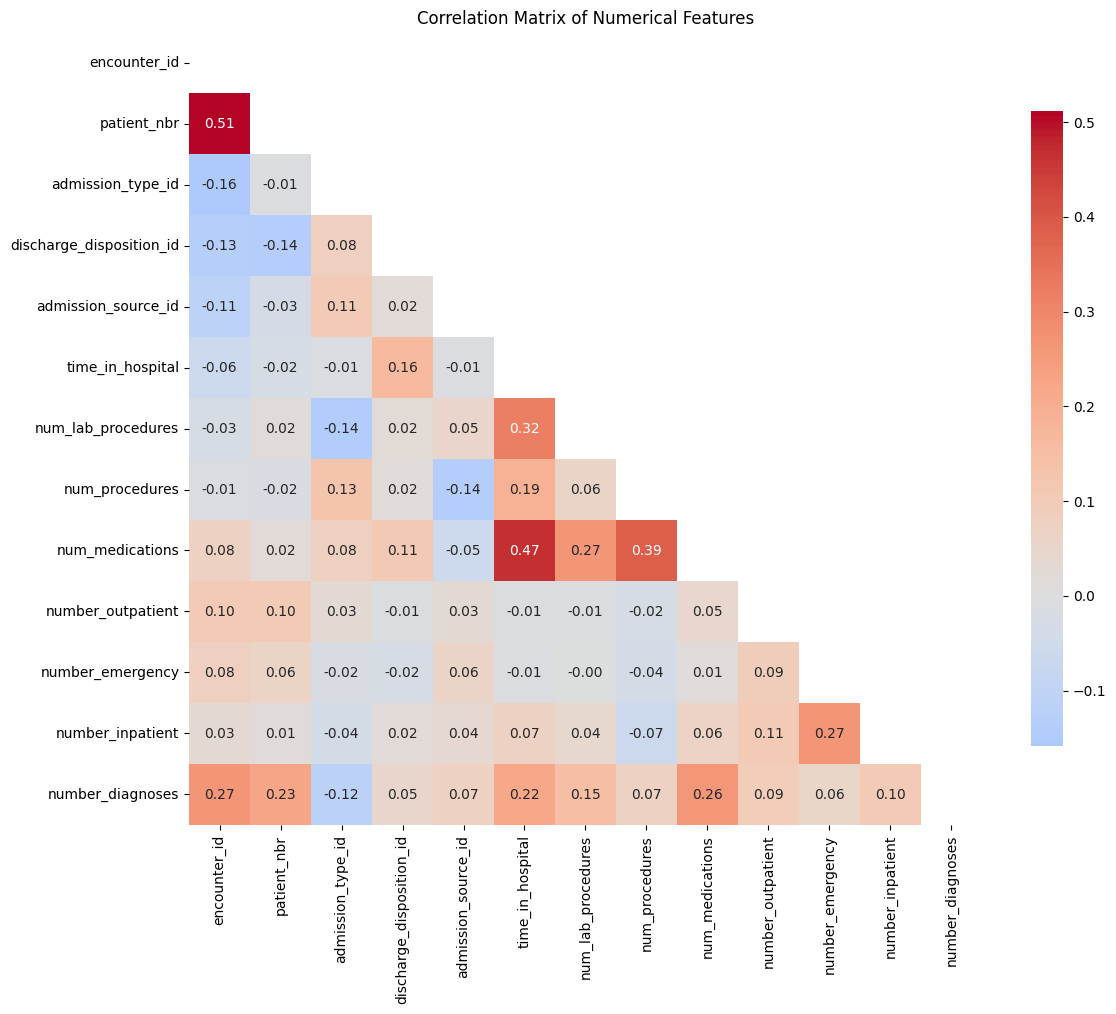

Highly correlated pairs (|correlation| > 0.5):
encounter_id - patient_nbr: 0.512


In [10]:
# Calculate correlation matrix for numerical features
if len(numerical_cols) > 1:
    correlation_matrix = data[numerical_cols].corr()
    
    # Plot correlation heatmap
    plt.figure(figsize=(12, 10))
    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
    sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', center=0,
                square=True, fmt='.2f', cbar_kws={"shrink": .8})
    plt.title('Correlation Matrix of Numerical Features')
    plt.tight_layout()
    plt.show()
    
    # Find highly correlated pairs
    high_corr_pairs = []
    for i in range(len(correlation_matrix.columns)):
        for j in range(i+1, len(correlation_matrix.columns)):
            corr_val = correlation_matrix.iloc[i, j]
            if abs(corr_val) > 0.5:  # threshold for high correlation
                high_corr_pairs.append((correlation_matrix.columns[i], correlation_matrix.columns[j], corr_val))
    
    if high_corr_pairs:
        print("Highly correlated pairs (|correlation| > 0.5):")
        for col1, col2, corr in high_corr_pairs:
            print(f"{col1} - {col2}: {corr:.3f}")
    else:
        print("No highly correlated pairs found (threshold: |correlation| > 0.5)")
else:
    print("Insufficient numerical columns for correlation analysis")

# IV. Categorical Features Analysis

## 1. Identify Categorical Columns

In [11]:
# Identify categorical columns
categorical_cols = data.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns ({len(categorical_cols)}):")
print(categorical_cols)

# Get basic information about categorical features
print("\nUnique values count for each categorical feature:")
for col in categorical_cols:
    unique_count = data[col].nunique()
    print(f"{col}: {unique_count} unique values")
    if unique_count <= 10:  # Show unique values for features with few categories
        print(f"  Values: {data[col].unique()}")
    print()

Categorical columns (37):
['race', 'gender', 'age', 'weight', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']

Unique values count for each categorical feature:
race: 6 unique values
  Values: ['Caucasian' 'AfricanAmerican' '?' 'Other' 'Asian' 'Hispanic']

gender: 3 unique values
  Values: ['Female' 'Male' 'Unknown/Invalid']

age: 10 unique values
  Values: ['[0-10)' '[10-20)' '[20-30)' '[30-40)' '[40-50)' '[50-60)' '[60-70)'
 '[70-80)' '[80-90)' '[90-100)']

weight: 10 unique values
  Values: ['?' '[75-100)' '[50-75)' '[0-

## 2. Key Categorical Features Analysis

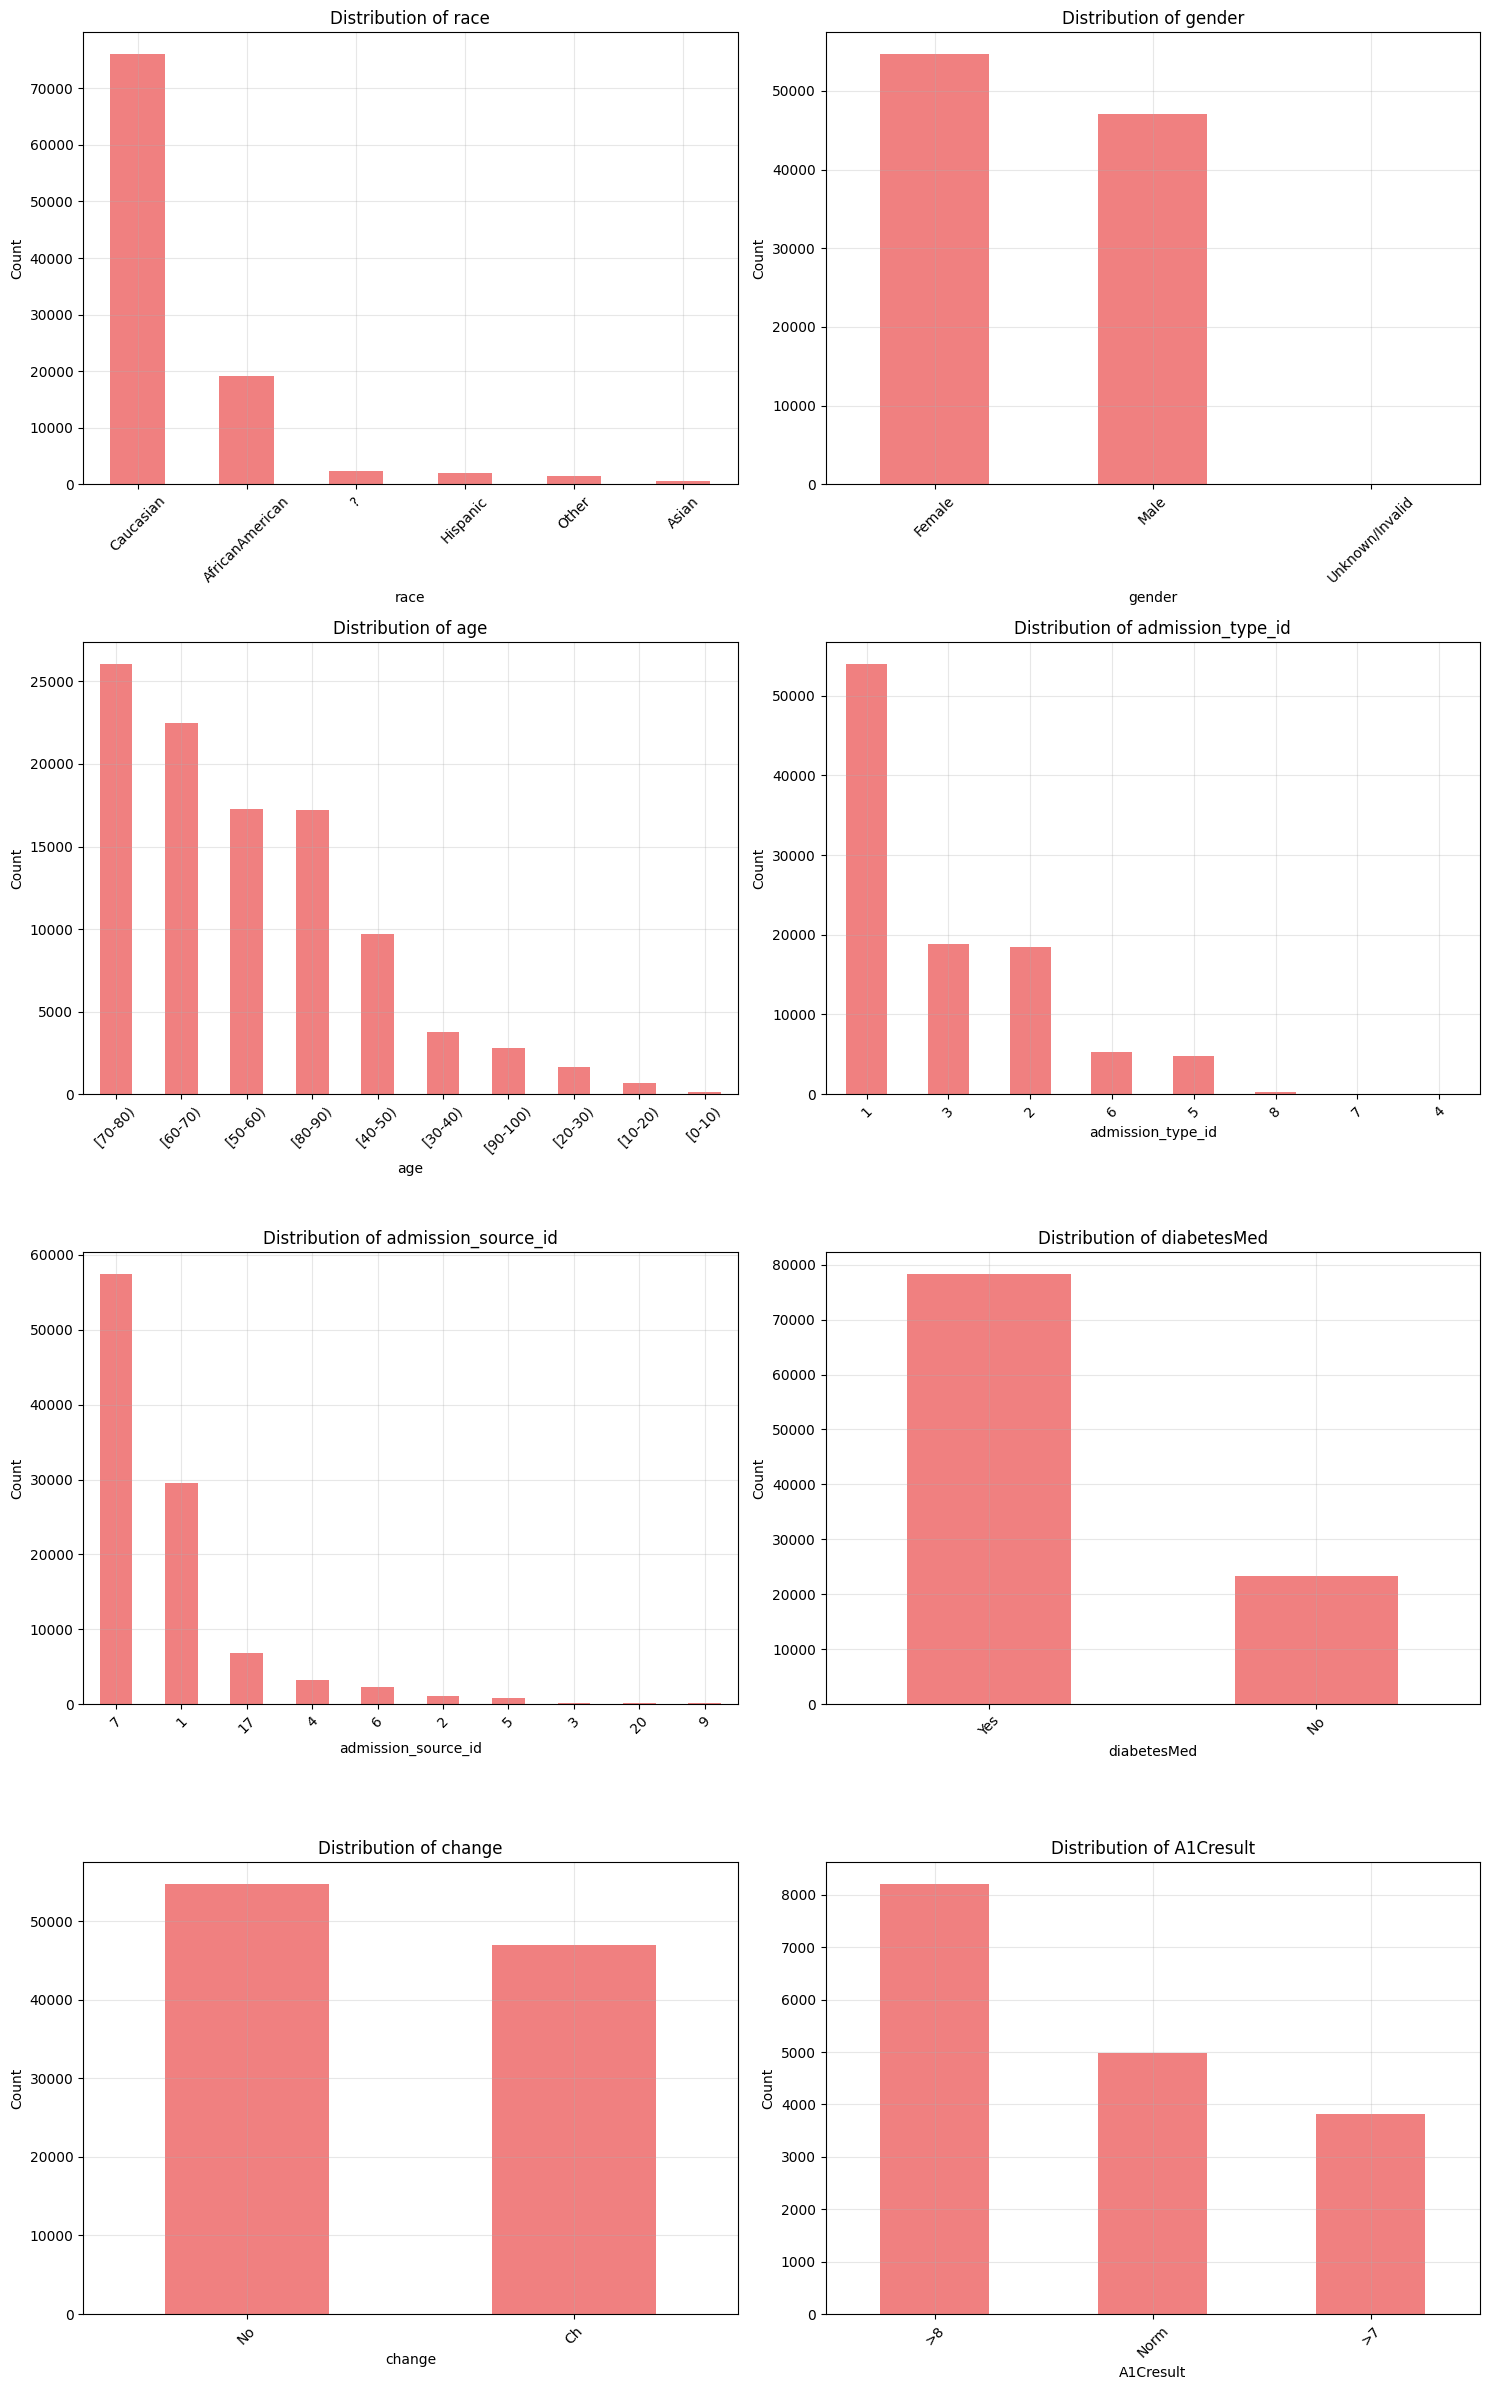

In [12]:
# Analyze key categorical features with manageable unique values for visualization
key_categorical_features = ['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 
                           'admission_source_id', 'diabetesMed', 'change', 'A1Cresult']

# Filter to only include columns that exist and have reasonable number of unique values
visualizable_features = []
for col in key_categorical_features:
    if col in data.columns and data[col].nunique() <= 20:
        visualizable_features.append(col)

# If no key features found, use the ones with fewer unique values
if not visualizable_features:
    visualizable_features = [col for col in categorical_cols if data[col].nunique() <= 20][:6]

if visualizable_features:
    n_cols = 2
    n_rows = (len(visualizable_features) + n_cols - 1) // n_cols
    
    plt.figure(figsize=(15, 6 * n_rows))
    
    for i, feature in enumerate(visualizable_features, 1):
        plt.subplot(n_rows, n_cols, i)
        value_counts = data[feature].value_counts().head(10)  # Top 10 categories
        value_counts.plot(kind='bar', color='lightcoral')
        plt.title(f'Distribution of {feature}')
        plt.xlabel(feature)
        plt.ylabel('Count')
        plt.xticks(rotation=45)
        plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("No suitable categorical features found for visualization")

# V. Feature Relationships with Target Variable

## 1. Numerical Features vs Target

C:\Users\aupho\AppData\Local\Temp\ipykernel_13008\1715736198.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=readmission_categories)
C:\Users\aupho\AppData\Local\Temp\ipykernel_13008\1715736198.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=readmission_categories)
C:\Users\aupho\AppData\Local\Temp\ipykernel_13008\1715736198.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=readmission_categories)
C:\Users\aupho\AppData\Local\Temp\ipykernel_13008\1715736198.py:18: MatplotlibDeprecationWarning: The 'labels' p

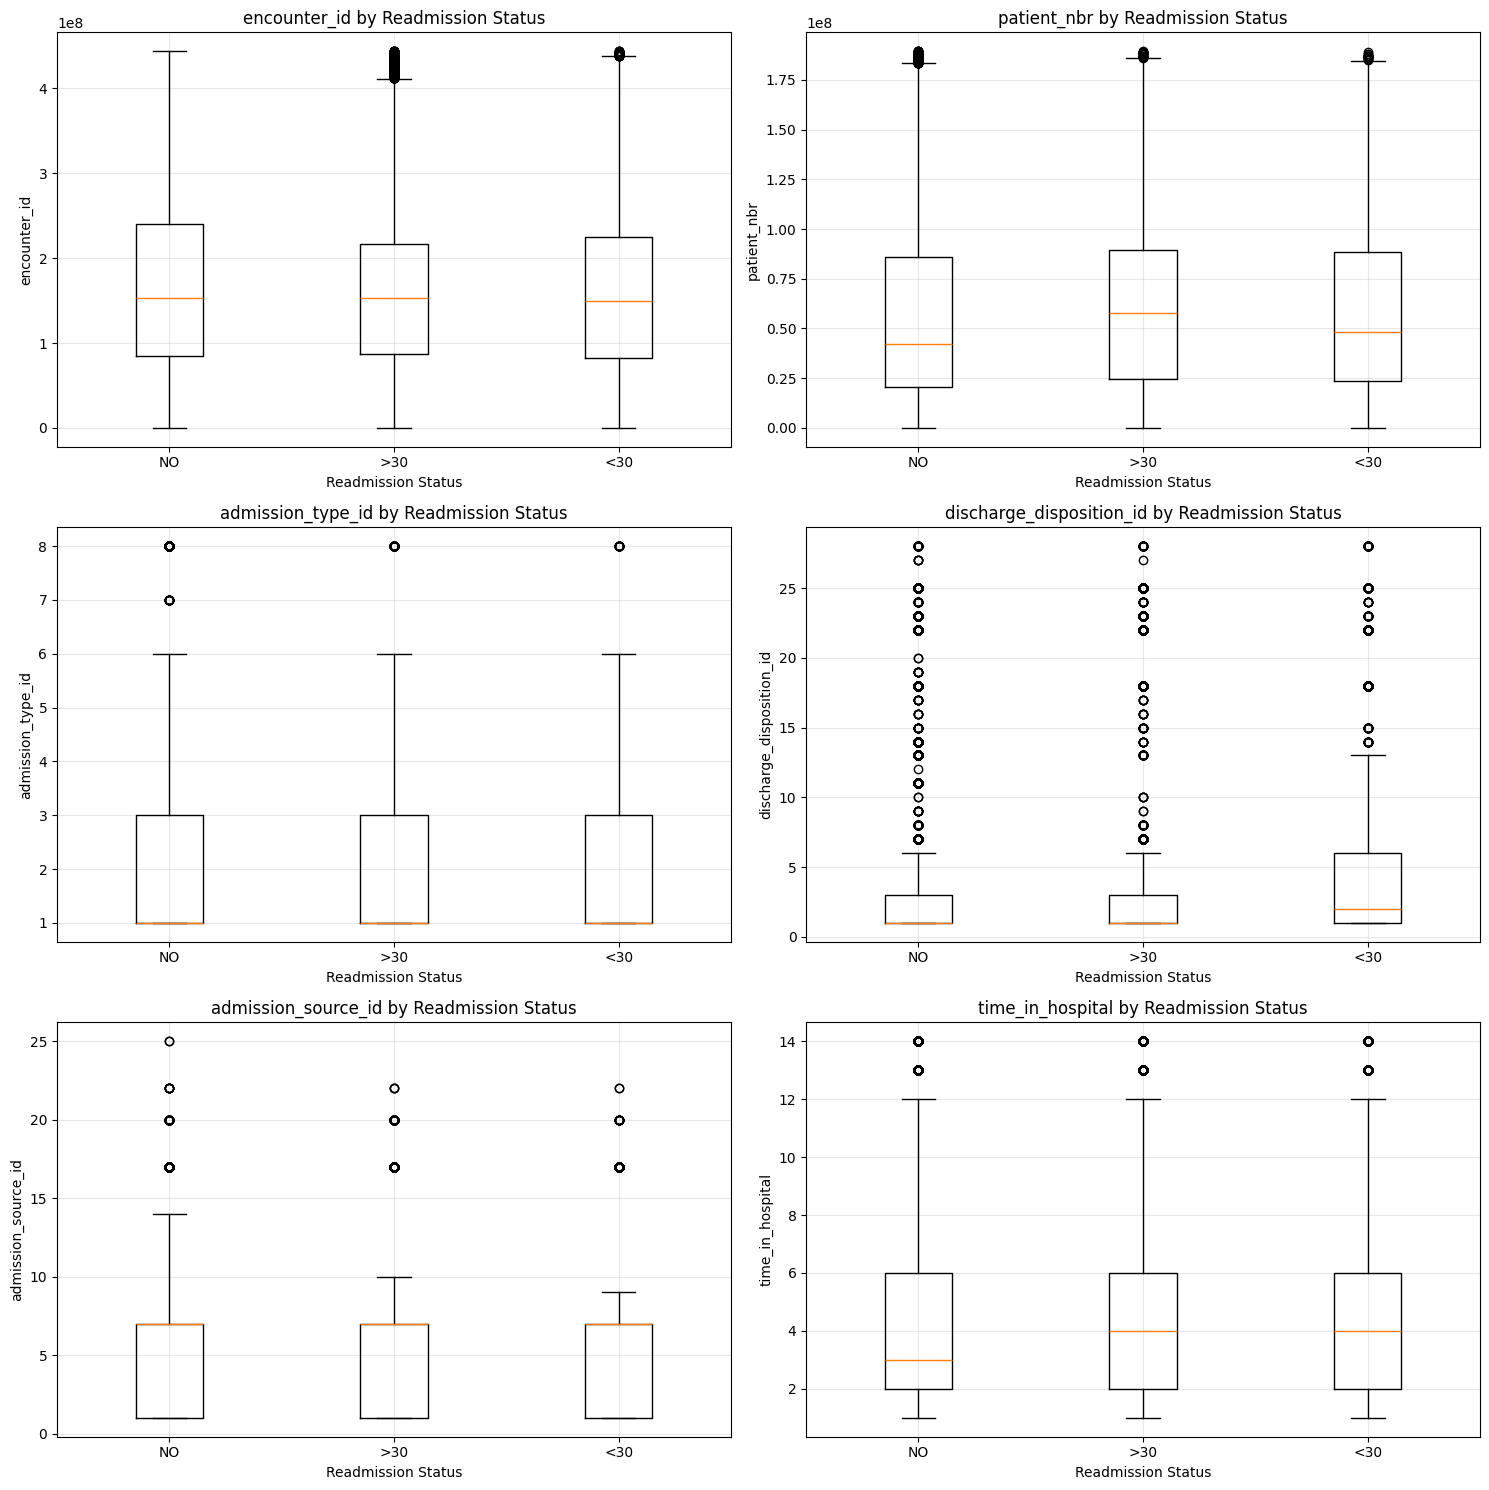

Statistical Summary by Readmission Status:

encounter_id:
                    mean       median           std
readmitted                                         
<30         1.627347e+08  149771196.0  1.017773e+08
>30         1.603845e+08  152753844.0  9.621249e+07
NO          1.688332e+08  152685498.0  1.066327e+08

patient_nbr:
                   mean      median          std
readmitted                                      
<30         55192187.81  48139200.0  37804416.60
>30         58146748.38  57902751.0  36614252.71
NO          51679493.10  42381697.5  39956951.91

admission_type_id:
            mean  median   std
readmitted                    
<30         1.98     1.0  1.42
>30         2.03     1.0  1.49
NO          2.03     1.0  1.42

discharge_disposition_id:
            mean  median   std
readmitted                    
<30         4.47     2.0  6.08
>30         3.36     1.0  4.84
NO          3.79     1.0  5.36

admission_source_id:
            mean  median   std
readmitted   

In [13]:
# Analyze relationship between numerical features and target variable
if numerical_cols and 'readmitted' in data.columns:
    # Select a subset of numerical features for visualization
    features_to_plot = numerical_cols[:6] if len(numerical_cols) > 6 else numerical_cols
    
    n_cols = 2
    n_rows = (len(features_to_plot) + n_cols - 1) // n_cols
    
    plt.figure(figsize=(15, 5 * n_rows))
    
    for i, feature in enumerate(features_to_plot, 1):
        plt.subplot(n_rows, n_cols, i)
        
        # Create box plot for each readmission category
        readmission_categories = data['readmitted'].unique()
        data_to_plot = [data[data['readmitted'] == cat][feature].dropna() for cat in readmission_categories]
        
        plt.boxplot(data_to_plot, labels=readmission_categories)
        plt.title(f'{feature} by Readmission Status')
        plt.xlabel('Readmission Status')
        plt.ylabel(feature)
        plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Statistical summary by target variable
    print("Statistical Summary by Readmission Status:")
    for feature in features_to_plot:
        print(f"\n{feature}:")
        summary = data.groupby('readmitted')[feature].agg(['mean', 'median', 'std']).round(2)
        print(summary)
else:
    print("Unable to analyze numerical features vs target variable")

## 2. Categorical Features vs Target


=== race vs Readmission ===
Cross-tabulation:
readmitted         <30    >30     NO     All
race                                        
?                  188    538   1547    2273
AfricanAmerican   2155   6634  10421   19210
Asian               65    161    415     641
Caucasian         8592  27124  40383   76099
Hispanic           212    642   1183    2037
Other              145    446    915    1506
All              11357  35545  54864  101766

Percentages by row:
readmitted        <30   >30    NO
race                             
?                 8.3  23.7  68.1
AfricanAmerican  11.2  34.5  54.2
Asian            10.1  25.1  64.7
Caucasian        11.3  35.6  53.1
Hispanic         10.4  31.5  58.1
Other             9.6  29.6  60.8


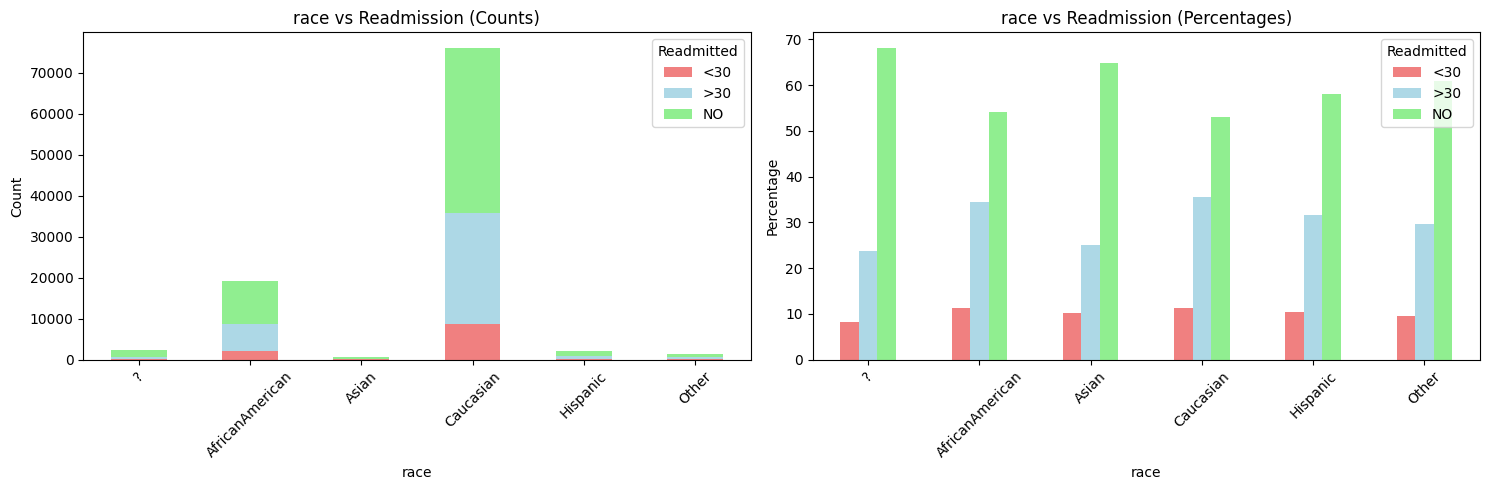

--------------------------------------------------

=== gender vs Readmission ===
Cross-tabulation:
readmitted         <30    >30     NO     All
gender                                      
Female            6152  19518  29038   54708
Male              5205  16027  25823   47055
Unknown/Invalid      0      0      3       3
All              11357  35545  54864  101766

Percentages by row:
readmitted        <30   >30     NO
gender                            
Female           11.2  35.7   53.1
Male             11.1  34.1   54.9
Unknown/Invalid   0.0   0.0  100.0


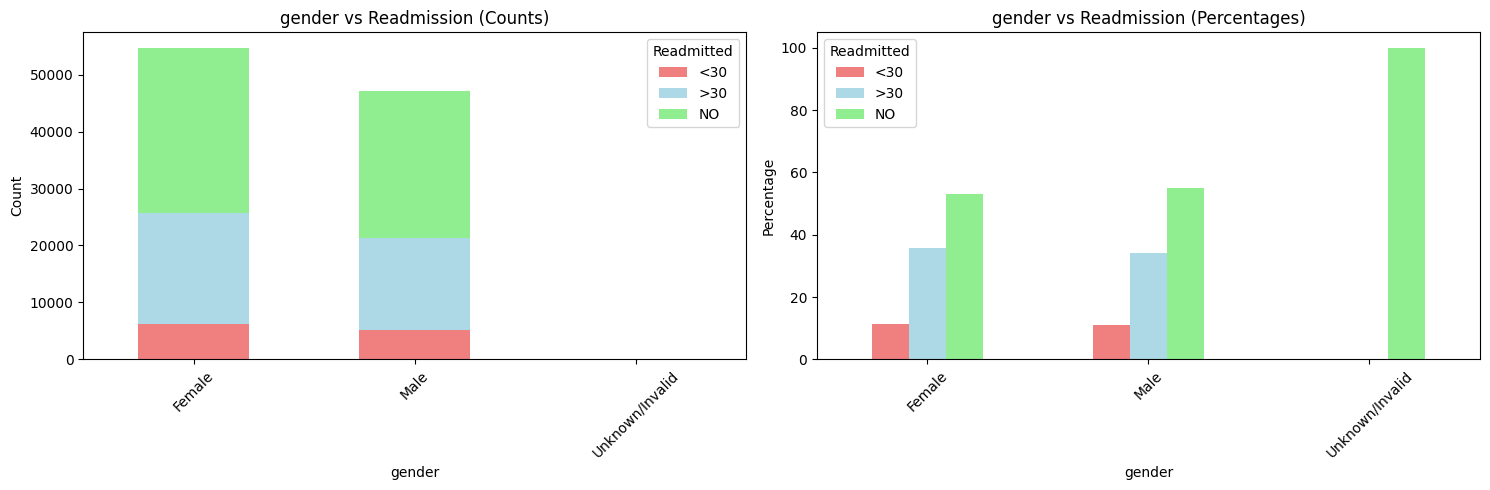

--------------------------------------------------

=== age vs Readmission ===
Cross-tabulation:
readmitted    <30    >30     NO     All
age                                    
[0-10)          3     26    132     161
[10-20)        40    224    427     691
[20-30)       236    510    911    1657
[30-40)       424   1187   2164    3775
[40-50)      1027   3278   5380    9685
[50-60)      1668   5917   9671   17256
[60-70)      2502   7897  12084   22483
[70-80)      3069   9475  13524   26068
[80-90)      2078   6223   8896   17197
[90-100)      310    808   1675    2793
All         11357  35545  54864  101766

Percentages by row:
readmitted   <30   >30    NO
age                         
[0-10)       1.9  16.1  82.0
[10-20)      5.8  32.4  61.8
[20-30)     14.2  30.8  55.0
[30-40)     11.2  31.4  57.3
[40-50)     10.6  33.8  55.5
[50-60)      9.7  34.3  56.0
[60-70)     11.1  35.1  53.7
[70-80)     11.8  36.3  51.9
[80-90)     12.1  36.2  51.7
[90-100)    11.1  28.9  60.0


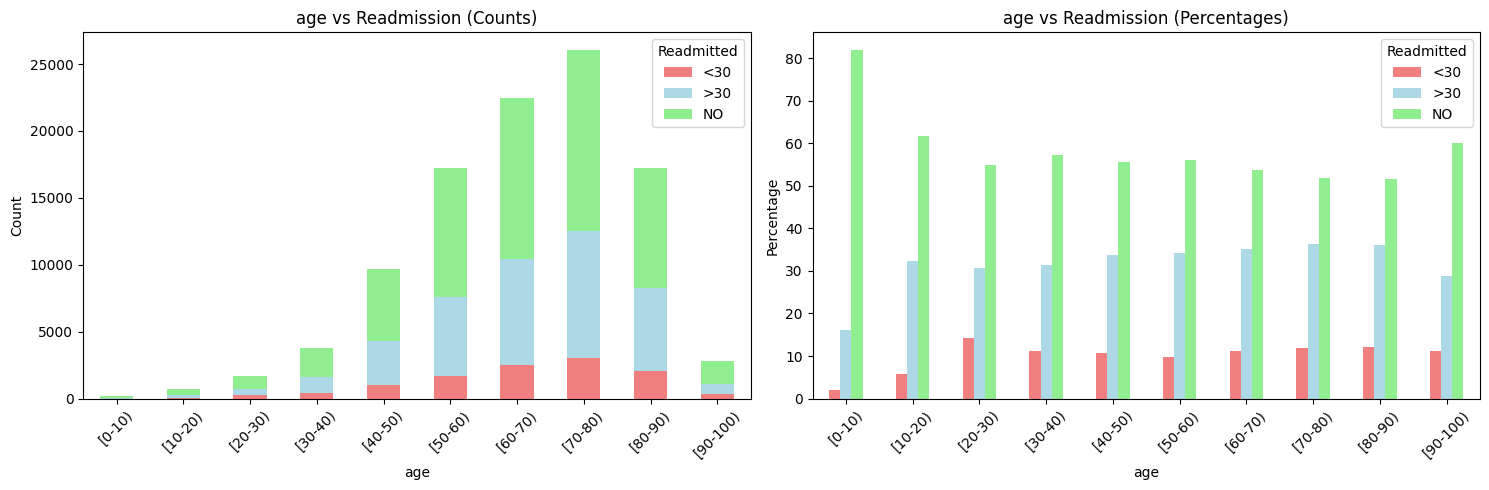

--------------------------------------------------

=== admission_type_id vs Readmission ===
Cross-tabulation:
readmitted           <30    >30     NO     All
admission_type_id                             
1                   6221  19309  28460   53990
2                   2066   6452   9962   18480
3                   1961   5746  11162   18869
4                      1      2      7      10
5                    495   1721   2569    4785
6                    586   2231   2474    5291
7                      0      0     21      21
8                     27     84    209     320
All                11357  35545  54864  101766

Percentages by row:
readmitted          <30   >30     NO
admission_type_id                   
1                  11.5  35.8   52.7
2                  11.2  34.9   53.9
3                  10.4  30.5   59.2
4                  10.0  20.0   70.0
5                  10.3  36.0   53.7
6                  11.1  42.2   46.8
7                   0.0   0.0  100.0
8                 

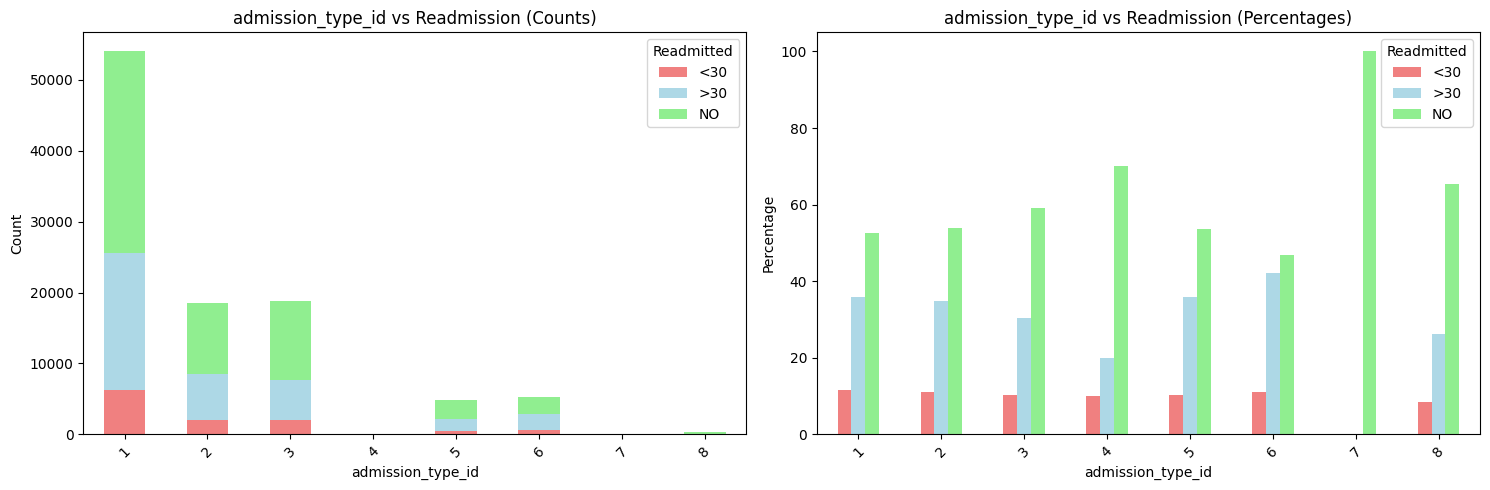

--------------------------------------------------


In [14]:
# Analyze relationship between categorical features and target variable
if visualizable_features and 'readmitted' in data.columns:
    # Select features for analysis
    features_to_analyze = visualizable_features[:4] if len(visualizable_features) > 4 else visualizable_features
    
    for feature in features_to_analyze:
        print(f"\n=== {feature} vs Readmission ===")
        
        # Create crosstab
        crosstab = pd.crosstab(data[feature], data['readmitted'], margins=True)
        print("Cross-tabulation:")
        print(crosstab)
        
        # Calculate percentages
        crosstab_pct = pd.crosstab(data[feature], data['readmitted'], normalize='index').round(3) * 100
        print("\nPercentages by row:")
        print(crosstab_pct)
        
        # Visualization
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
        
        # Stacked bar chart
        crosstab_no_margins = pd.crosstab(data[feature], data['readmitted'])
        crosstab_no_margins.plot(kind='bar', stacked=True, ax=ax1, color=['lightcoral', 'lightblue', 'lightgreen'])
        ax1.set_title(f'{feature} vs Readmission (Counts)')
        ax1.set_xlabel(feature)
        ax1.set_ylabel('Count')
        ax1.legend(title='Readmitted')
        ax1.tick_params(axis='x', rotation=45)
        
        # Percentage bar chart
        crosstab_pct.plot(kind='bar', ax=ax2, color=['lightcoral', 'lightblue', 'lightgreen'])
        ax2.set_title(f'{feature} vs Readmission (Percentages)')
        ax2.set_xlabel(feature)
        ax2.set_ylabel('Percentage')
        ax2.legend(title='Readmitted')
        ax2.tick_params(axis='x', rotation=45)
        
        plt.tight_layout()
        plt.show()
        print("-" * 50)
else:
    print("Unable to analyze categorical features vs target variable")

# VI. Data Quality Assessment

In [15]:
# Data Quality Assessment
print("=== DATA QUALITY ASSESSMENT ===\n")

# 1. Duplicate rows
duplicate_count = data.duplicated().sum()
print(f"1. Duplicate rows: {duplicate_count} ({duplicate_count/len(data)*100:.2f}%)")

# 2. Missing values summary
total_missing = data.isnull().sum().sum()
print(f"2. Total missing values: {total_missing}")

# 3. Columns with high cardinality (potential issues)
high_cardinality_cols = []
for col in categorical_cols:
    unique_ratio = data[col].nunique() / len(data)
    if unique_ratio > 0.5:  # More than 50% unique values
        high_cardinality_cols.append((col, data[col].nunique(), unique_ratio))

if high_cardinality_cols:
    print("3. High cardinality categorical columns (>50% unique values):")
    for col, unique_count, ratio in high_cardinality_cols:
        print(f"   {col}: {unique_count} unique values ({ratio:.2%})")
else:
    print("3. No high cardinality categorical columns detected")

# 4. Outliers in numerical features (using IQR method)
print("4. Potential outliers in numerical features:")
for col in numerical_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
    print(f"   {col}: {len(outliers)} potential outliers ({len(outliers)/len(data)*100:.2f}%)")

# 5. Data types appropriateness
print("5. Data types summary:")
print(f"   Numerical columns: {len(numerical_cols)}")
print(f"   Categorical columns: {len(categorical_cols)}")
print(f"   Total columns: {len(data.columns)}")

# 6. Target variable balance
if 'readmitted' in data.columns:
    target_balance = data['readmitted'].value_counts(normalize=True).min()
    print(f"6. Target variable balance (minority class): {target_balance:.2%}")
    if target_balance < 0.1:
        print("   ⚠️ Highly imbalanced dataset detected!")
    elif target_balance < 0.3:
        print("   ⚠️ Moderately imbalanced dataset")
    else:
        print("   ✓ Reasonably balanced dataset")

=== DATA QUALITY ASSESSMENT ===

1. Duplicate rows: 0 (0.00%)
2. Total missing values: 181168
3. No high cardinality categorical columns detected
4. Potential outliers in numerical features:
   encounter_id: 0 potential outliers (0.00%)
   patient_nbr: 247 potential outliers (0.24%)
   admission_type_id: 341 potential outliers (0.34%)
   discharge_disposition_id: 9818 potential outliers (9.65%)
   admission_source_id: 6956 potential outliers (6.84%)
   time_in_hospital: 2252 potential outliers (2.21%)
   num_lab_procedures: 143 potential outliers (0.14%)
   num_procedures: 4954 potential outliers (4.87%)
   num_medications: 2557 potential outliers (2.51%)
   number_outpatient: 16739 potential outliers (16.45%)
   number_emergency: 11383 potential outliers (11.19%)
   number_inpatient: 7049 potential outliers (6.93%)
   number_diagnoses: 281 potential outliers (0.28%)
5. Data types summary:
   Numerical columns: 13
   Categorical columns: 37
   Total columns: 50
6. Target variable balan

# VII. Key Insights and Recommendations

## Key Findings from Healthcare EDA

**Business Goal Alignment:**
- **Primary Target**: 30-day readmission prediction (11.2% of cases)
- **Operational Impact**: 46.1% of patients have some form of readmission (30-day + >30-day)
- **Intervention Opportunity**: Clear risk factors identified for targeted care pathways

**Clinical Insights:**
- Length of stay, medication management, and prior utilization are key predictors
- Demographic disparities exist that require fairness considerations
- High-complexity patients (multiple diagnoses/medications) show elevated risk
- Discharge disposition significantly impacts readmission likelihood

**Data Quality for Modeling:**
- Strong dataset: 101,766 patients with comprehensive clinical features
- Missing data challenges in key clinical measures (A1C: 83%, weight: 97%)
- Good feature diversity for risk modeling and intervention design

**Fairness and Equity Considerations:**
- Significant demographic differences in readmission rates detected
- Race, age, and gender show varying risk patterns requiring bias mitigation
- Statistical testing confirms significant group differences

## Healthcare-Specific Recommendations

### 1. **Risk Modeling & Calibration**
- **Primary Model**: Binary classification for 30-day vs no/late readmission
- **Key Features**: Length of stay, prior utilization, medication complexity, demographics
- **Calibration Focus**: Ensure predictions are well-calibrated across demographic groups
- **Fairness Metrics**: Implement equalized odds and demographic parity checks
- **Validation Strategy**: Temporal validation (train on early years, test on later years)

### 2. **Care Pathway Interventions**
- **High-Risk Targeting**: Focus on top 20-30% risk patients for maximum ROI
- **Medication Management**: Prioritize diabetes medication adherence programs
- **Discharge Planning**: Enhanced protocols for high-risk discharge dispositions
- **Transition Care**: Special attention to patients with complex care needs (multiple diagnoses/medications)
- **Prior Utilization**: Proactive outreach for patients with previous emergency visits

### 3. **Dashboard & Operational Analytics**
- **Real-time Risk Scoring**: Integrate risk model into EHR workflow
- **Care Team Alerts**: Automated notifications for high-risk patients
- **Intervention Tracking**: Monitor effectiveness of care pathway changes
- **ROI Monitoring**: Track prevented readmissions and cost savings
- **Fairness Monitoring**: Ongoing bias detection and mitigation

### 4. **Intervention ROI Framework**
- **Cost-Benefit Analysis**: ~$15K per readmission vs ~$500 intervention cost
- **Break-even Point**: Need >3.3% reduction in readmissions for positive ROI
- **Target Scenarios**: 10-20% reduction rates show strong ROI potential
- **High-Risk Focus**: Targeting top-risk patients improves ROI significantly
- **Scalability**: Start with pilot programs before full implementation

### 5. **Model Development Priorities**
```python
# Recommended modeling approach:
1. Feature Engineering:
   - Risk scores from clinical complexity
   - Medication adherence indicators  
   - Care utilization patterns
   - Demographic fairness features

2. Model Selection:
   - Gradient Boosting (XGBoost/LightGBM) for performance
   - Logistic Regression for interpretability
   - Ensemble methods for robustness

3. Fairness Integration:
   - Pre-processing: Demographic parity
   - In-processing: Fairness constraints
   - Post-processing: Threshold optimization

4. Calibration Methods:
   - Platt scaling for probability calibration
   - Isotonic regression for non-linear calibration
   - Group-specific calibration for fairness
```

### 6. **Implementation Roadmap**
1. **Phase 1** (Months 1-2): Model development and validation
2. **Phase 2** (Months 3-4): Pilot deployment with high-risk cohort
3. **Phase 3** (Months 5-6): Care pathway integration and staff training
4. **Phase 4** (Months 7+): Full deployment and continuous monitoring

### 7. **Success Metrics**
- **Clinical**: 30-day readmission rate reduction
- **Operational**: Care team workflow integration
- **Financial**: ROI from prevented readmissions
- **Equity**: Fairness metrics across demographic groups
- **Patient**: Satisfaction and outcomes improvement

# VIII. Healthcare-Specific Analysis

## 1. 30-Day Readmission Focus Analysis

=== 30-DAY READMISSION ANALYSIS ===
Total patients: 101,766
30-day readmissions: 11,357 (11.16%)
No readmission or >30 days: 90,409 (88.84%)

=== CLINICAL RISK FACTORS FOR 30-DAY READMISSION ===

1. Length of Stay vs 30-day Readmission:
                  Total_Patients  30day_Readmissions  Readmission_Rate
time_in_hospital                                                      
1                          14208                1162             0.082
2                          17224                1712             0.099
3                          17756                1894             0.107
4                          13924                1644             0.118
5                           9966                1199             0.120
6                           7539                 949             0.126
7                           5859                 752             0.128
8                           4391                 625             0.142
9                           3002                 412 

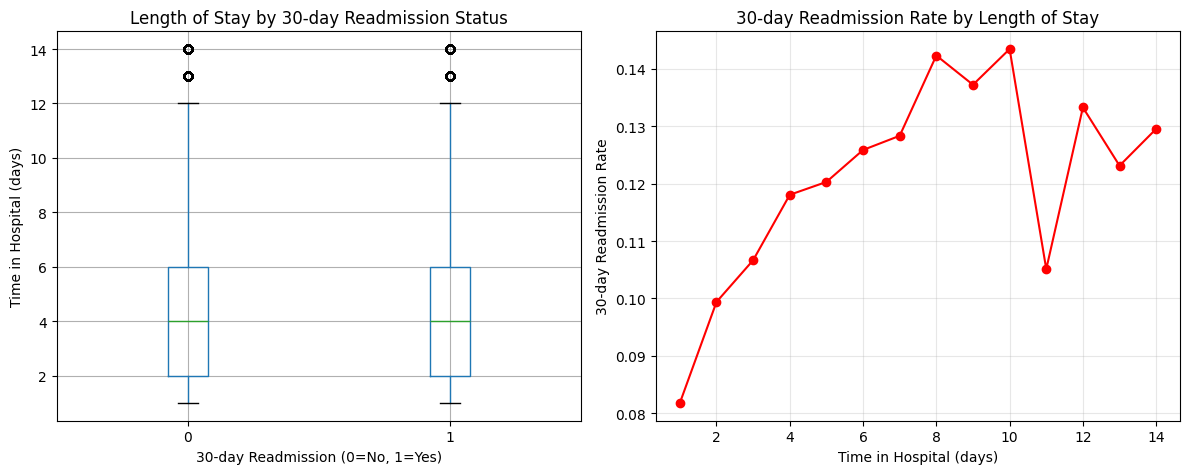

In [16]:
# Create binary target for 30-day readmission prediction
data['readmitted_30day'] = (data['readmitted'] == '<30').astype(int)

print("=== 30-DAY READMISSION ANALYSIS ===")
print(f"Total patients: {len(data):,}")
print(f"30-day readmissions: {data['readmitted_30day'].sum():,} ({data['readmitted_30day'].mean()*100:.2f}%)")
print(f"No readmission or >30 days: {(data['readmitted_30day'] == 0).sum():,} ({(1-data['readmitted_30day'].mean())*100:.2f}%)")

# Analyze readmission by key clinical factors
print("\n=== CLINICAL RISK FACTORS FOR 30-DAY READMISSION ===")

# Length of stay analysis
print("\n1. Length of Stay vs 30-day Readmission:")
length_stay_analysis = data.groupby('time_in_hospital')['readmitted_30day'].agg(['count', 'sum', 'mean']).round(3)
length_stay_analysis.columns = ['Total_Patients', '30day_Readmissions', 'Readmission_Rate']
print(length_stay_analysis.head(10))

# Visualize length of stay impact
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
data.boxplot(column='time_in_hospital', by='readmitted_30day', ax=plt.gca())
plt.title('Length of Stay by 30-day Readmission Status')
plt.suptitle('')
plt.xlabel('30-day Readmission (0=No, 1=Yes)')
plt.ylabel('Time in Hospital (days)')

plt.subplot(1, 2, 2)
readmission_by_los = data.groupby('time_in_hospital')['readmitted_30day'].mean()
readmission_by_los.plot(kind='line', marker='o', color='red')
plt.title('30-day Readmission Rate by Length of Stay')
plt.xlabel('Time in Hospital (days)')
plt.ylabel('30-day Readmission Rate')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Medication Management Analysis

=== MEDICATION MANAGEMENT ANALYSIS ===

1. Diabetes Medication vs 30-day Readmission:
readmitted_30day      0      1
diabetesMed                   
No                0.904  0.096
Yes               0.884  0.116

2. Medication Changes vs 30-day Readmission:
readmitted_30day      0      1
change                        
Ch                0.882  0.118
No                0.894  0.106

3. A1C Result vs 30-day Readmission:
readmitted_30day      0      1
A1Cresult                     
>7                0.900  0.100
>8                0.901  0.099
Missing           0.886  0.114
Norm              0.903  0.097

4. Individual Diabetes Medications Analysis (Top 6 medications):

Metformin:
           Count  Readmission_Rate
metformin                         
Down         575             0.120
No         81778             0.115
Steady     18346             0.097
Up          1067             0.082

Insulin:
         Count  Readmission_Rate
insulin                         
Down     12218             0.139

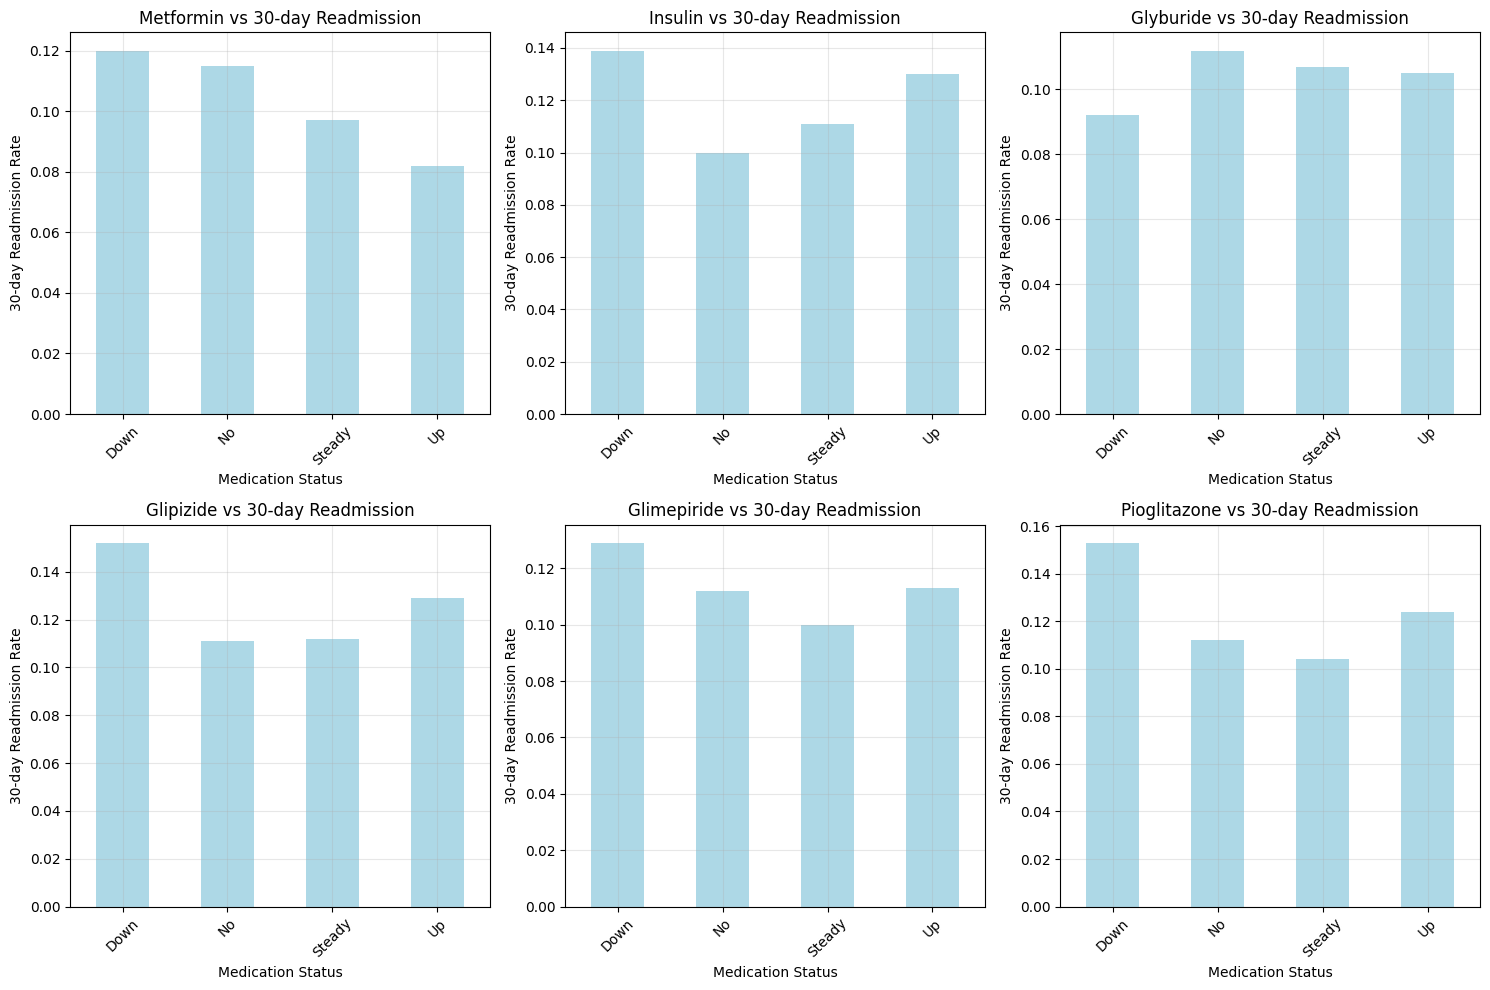

In [17]:
# Analyze medication-related factors for readmission
print("=== MEDICATION MANAGEMENT ANALYSIS ===")

# Diabetes medication management
print("\n1. Diabetes Medication vs 30-day Readmission:")
diabetes_med_analysis = pd.crosstab(data['diabetesMed'], data['readmitted_30day'], normalize='index').round(3)
print(diabetes_med_analysis)

print("\n2. Medication Changes vs 30-day Readmission:")
change_analysis = pd.crosstab(data['change'], data['readmitted_30day'], normalize='index').round(3)
print(change_analysis)

print("\n3. A1C Result vs 30-day Readmission:")
a1c_analysis = pd.crosstab(data['A1Cresult'].fillna('Missing'), data['readmitted_30day'], normalize='index').round(3)
print(a1c_analysis)

# Analyze key diabetes medications
diabetes_meds = ['metformin', 'insulin', 'glyburide', 'glipizide', 'glimepiride', 'pioglitazone']
existing_meds = [med for med in diabetes_meds if med in data.columns]

if existing_meds:
    print(f"\n4. Individual Diabetes Medications Analysis (Top {len(existing_meds)} medications):")
    
    plt.figure(figsize=(15, 10))
    
    for i, med in enumerate(existing_meds, 1):
        plt.subplot(2, 3, i)
        
        # Calculate readmission rates by medication status
        med_readmission = data.groupby(med)['readmitted_30day'].agg(['count', 'mean']).round(3)
        med_readmission.columns = ['Count', 'Readmission_Rate']
        
        med_readmission['Readmission_Rate'].plot(kind='bar', color='lightblue')
        plt.title(f'{med.title()} vs 30-day Readmission')
        plt.xlabel('Medication Status')
        plt.ylabel('30-day Readmission Rate')
        plt.xticks(rotation=45)
        plt.grid(True, alpha=0.3)
        
        print(f"\n{med.title()}:")
        print(med_readmission)
    
    plt.tight_layout()
    plt.show()

## 3. Demographics and Fairness Analysis

=== DEMOGRAPHICS AND FAIRNESS ANALYSIS ===

1. Race/Ethnicity vs 30-day Readmission:
Sample sizes by race:
race
Caucasian          76099
AfricanAmerican    19210
?                   2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64

Readmission rates by race:
readmitted_30day      0      1
race                          
AfricanAmerican   0.888  0.112
Asian             0.899  0.101
Caucasian         0.887  0.113
Hispanic          0.896  0.104
Other             0.904  0.096
Unknown           0.917  0.083

2. Gender vs 30-day Readmission:
readmitted_30day      0      1
gender                        
Female            0.888  0.112
Male              0.889  0.111
Unknown/Invalid   1.000  0.000

3. Age Group vs 30-day Readmission:
readmitted_30day      0      1
age                           
[0-10)            0.981  0.019
[10-20)           0.942  0.058
[20-30)           0.858  0.142
[30-40)           0.888  0.112
[40-50)           0.894 

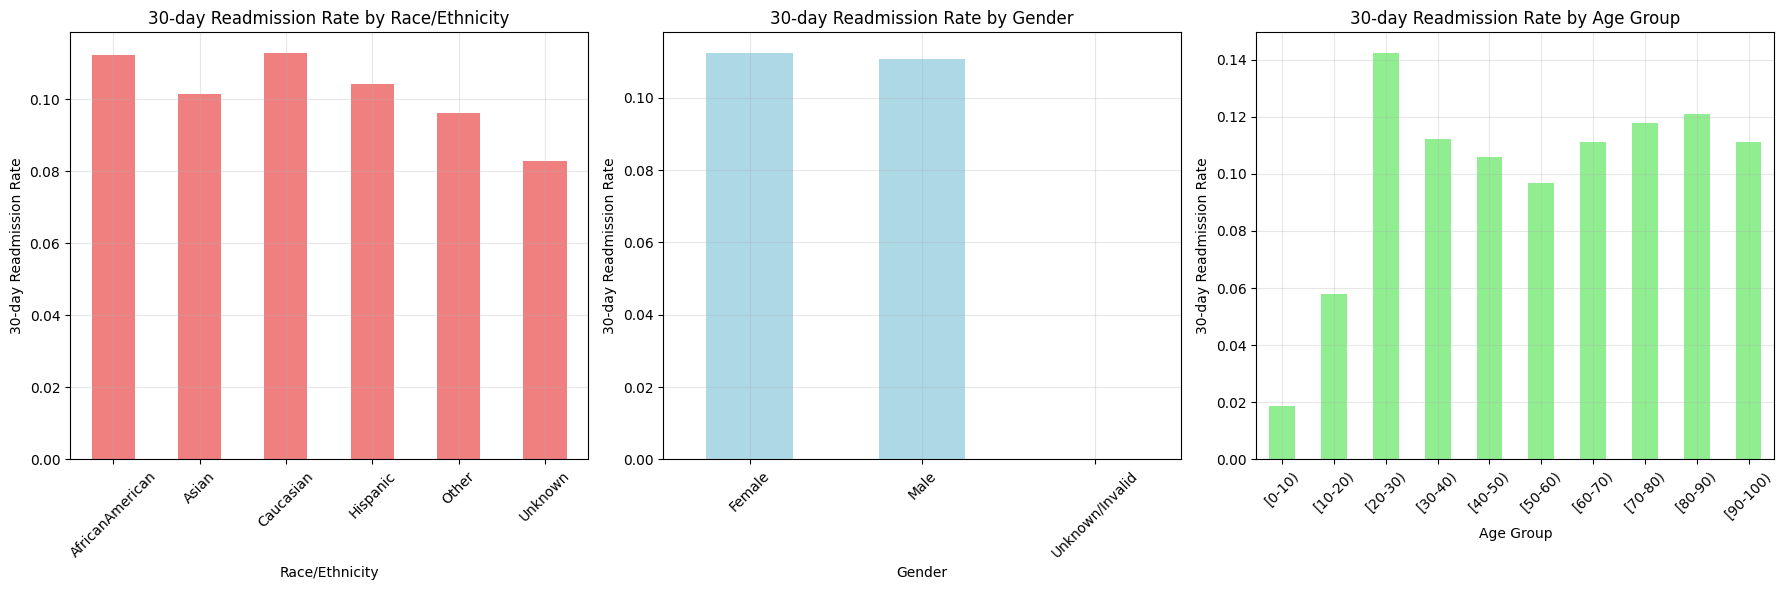


=== STATISTICAL SIGNIFICANCE TESTS ===
Chi-square tests for demographic differences:
Race: χ² = 25.908, p-value = 0.000093
Gender: χ² = 1.237, p-value = 0.538683
Age: χ² = 116.609, p-value = 0.000000

Interpretation: p < 0.05 indicates significant differences between groups


In [19]:
# Fairness analysis - critical for healthcare AI
print("=== DEMOGRAPHICS AND FAIRNESS ANALYSIS ===")

# Race/ethnicity analysis
print("\n1. Race/Ethnicity vs 30-day Readmission:")
race_clean = data['race'].replace('?', 'Unknown')
race_analysis = pd.crosstab(race_clean, data['readmitted_30day'], normalize='index').round(3)
race_counts = data['race'].value_counts()

print("Sample sizes by race:")
print(race_counts)
print("\nReadmission rates by race:")
print(race_analysis)

# Gender analysis
print("\n2. Gender vs 30-day Readmission:")
gender_analysis = pd.crosstab(data['gender'], data['readmitted_30day'], normalize='index').round(3)
print(gender_analysis)

# Age analysis
print("\n3. Age Group vs 30-day Readmission:")
age_analysis = pd.crosstab(data['age'], data['readmitted_30day'], normalize='index').round(3)
print(age_analysis)

# Visualize demographic disparities
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Race
race_readmission_rates = data.groupby(race_clean)['readmitted_30day'].mean()
race_readmission_rates.plot(kind='bar', ax=axes[0], color='lightcoral')
axes[0].set_title('30-day Readmission Rate by Race/Ethnicity')
axes[0].set_xlabel('Race/Ethnicity')
axes[0].set_ylabel('30-day Readmission Rate')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3)

# Gender
gender_readmission_rates = data.groupby('gender')['readmitted_30day'].mean()
gender_readmission_rates.plot(kind='bar', ax=axes[1], color='lightblue')
axes[1].set_title('30-day Readmission Rate by Gender')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('30-day Readmission Rate')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3)

# Age
age_readmission_rates = data.groupby('age')['readmitted_30day'].mean()
age_readmission_rates.plot(kind='bar', ax=axes[2], color='lightgreen')
axes[2].set_title('30-day Readmission Rate by Age Group')
axes[2].set_xlabel('Age Group')
axes[2].set_ylabel('30-day Readmission Rate')
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Statistical significance testing for fairness
from scipy.stats import chi2_contingency

print("\n=== STATISTICAL SIGNIFICANCE TESTS ===")
print("Chi-square tests for demographic differences:")

# Race
race_contingency = pd.crosstab(race_clean, data['readmitted_30day'])
chi2_race, p_race, dof_race, expected_race = chi2_contingency(race_contingency)
print(f"Race: χ² = {chi2_race:.3f}, p-value = {p_race:.6f}")

# Gender
gender_contingency = pd.crosstab(data['gender'], data['readmitted_30day'])
chi2_gender, p_gender, dof_gender, expected_gender = chi2_contingency(gender_contingency)
print(f"Gender: χ² = {chi2_gender:.3f}, p-value = {p_gender:.6f}")

# Age
age_contingency = pd.crosstab(data['age'], data['readmitted_30day'])
chi2_age, p_age, dof_age, expected_age = chi2_contingency(age_contingency)
print(f"Age: χ² = {chi2_age:.3f}, p-value = {p_age:.6f}")

print("\nInterpretation: p < 0.05 indicates significant differences between groups")

## 4. Care Pathway and Intervention Analysis

=== CARE PATHWAY AND INTERVENTION OPPORTUNITIES ===

1. Admission Type vs 30-day Readmission:
                   Patient_Count  Readmission_Rate
admission_type_id                                 
1                          53990             0.115
2                          18480             0.112
3                          18869             0.104
4                             10             0.100
5                           4785             0.103
6                           5291             0.111
7                             21             0.000
8                            320             0.084

Admission Type Details (with descriptions):
                                                    Patient_Count  \
description                                                         
 Court/Law Enforcement                                        320   
 Emergency Room                                                21   
 Physician Referral                                         53990   
 Trans

C:\Users\aupho\AppData\Local\Temp\ipykernel_13008\3744095050.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  util_analysis = data.groupby(f'{feature}_category')['readmitted_30day'].agg(['count', 'mean']).round(3)
C:\Users\aupho\AppData\Local\Temp\ipykernel_13008\3744095050.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  util_analysis = data.groupby(f'{feature}_category')['readmitted_30day'].agg(['count', 'mean']).round(3)
C:\Users\aupho\AppData\Local\Temp\ipykernel_13008\3744095050.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pa

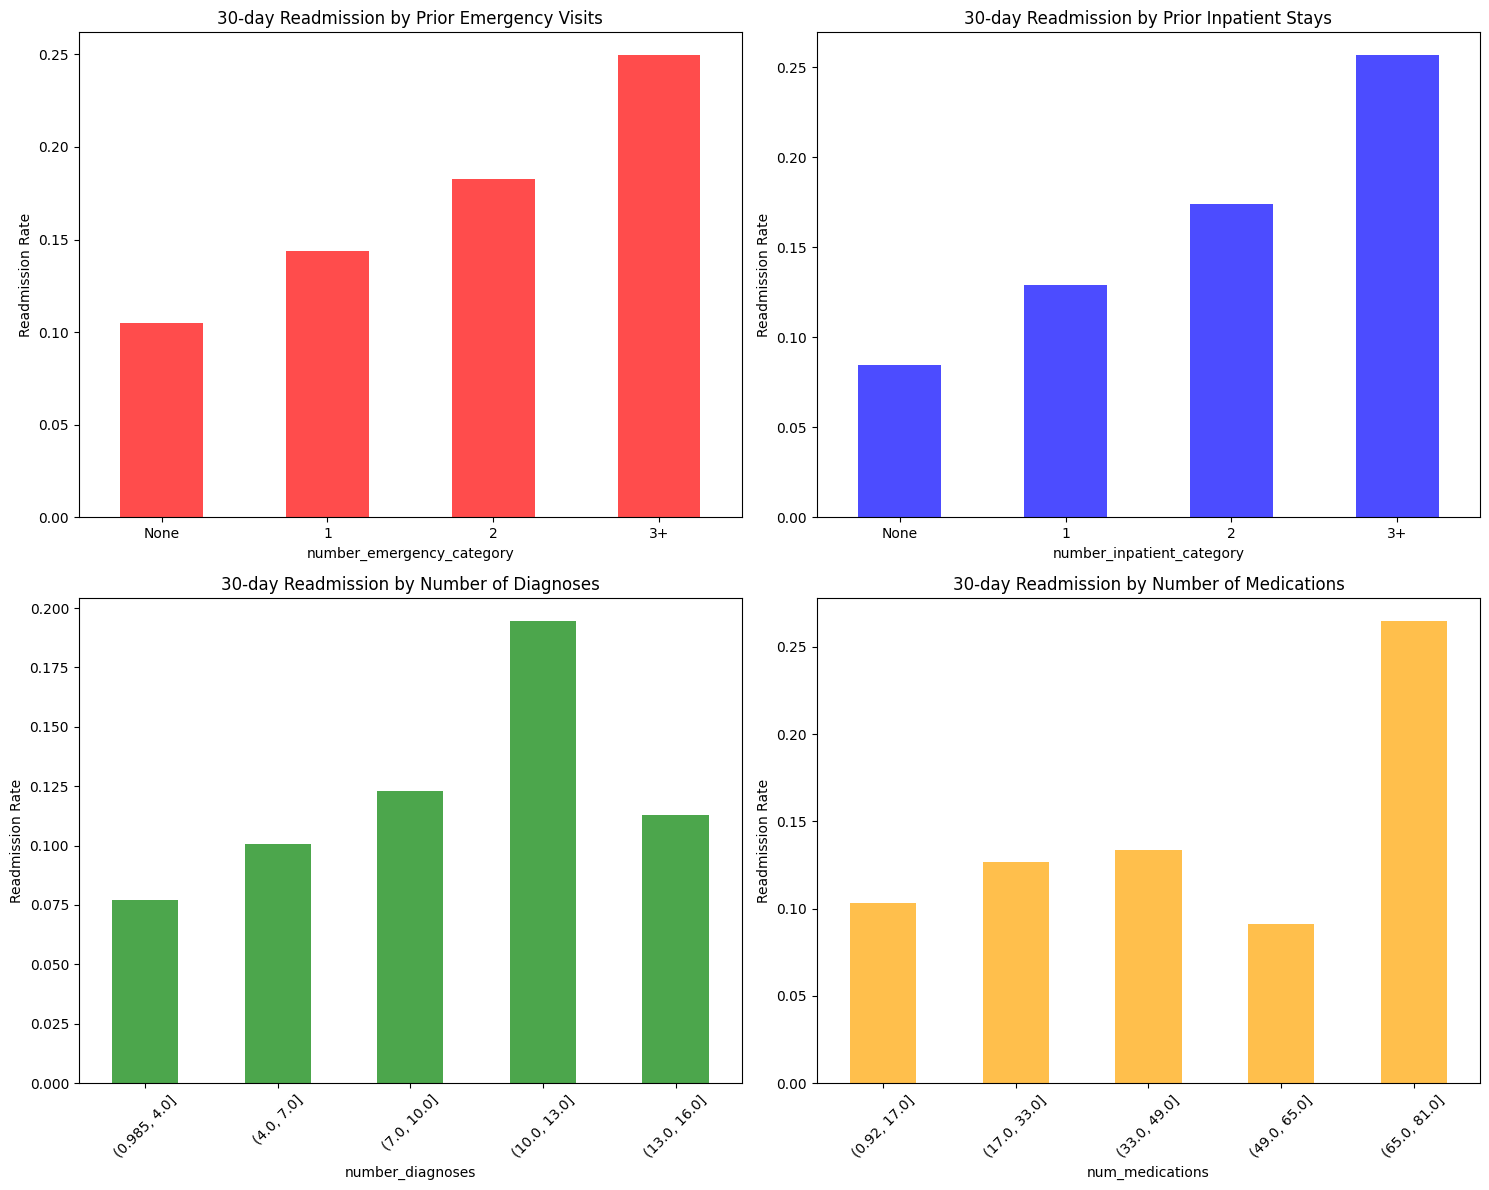

In [21]:
# Analyze factors that could inform care pathway interventions
print("=== CARE PATHWAY AND INTERVENTION OPPORTUNITIES ===")

# Load admission type mapping if available
if 'admission_type_id' in data.columns:
    print("\n1. Admission Type vs 30-day Readmission:")
    admission_analysis = data.groupby('admission_type_id')['readmitted_30day'].agg(['count', 'mean']).round(3)
    admission_analysis.columns = ['Patient_Count', 'Readmission_Rate']
    print(admission_analysis)
    
    # Map admission types using the mapping data
    if 'admission_type_id' in mapping.columns:
        # Convert data types to match before merging
        data_temp = data.copy()
        mapping_temp = mapping.copy()
        
        # Convert both to string type for consistent merging
        data_temp['admission_type_id'] = data_temp['admission_type_id'].astype(str)
        mapping_temp['admission_type_id'] = mapping_temp['admission_type_id'].astype(str)
        
        admission_mapped = data_temp.merge(mapping_temp, on='admission_type_id', how='left')
        print("\nAdmission Type Details (with descriptions):")
        admission_detailed = admission_mapped.groupby('description')['readmitted_30day'].agg(['count', 'mean']).round(3)
        admission_detailed.columns = ['Patient_Count', 'Readmission_Rate']
        print(admission_detailed)

# Discharge disposition analysis
print("\n2. Discharge Disposition vs 30-day Readmission:")
discharge_analysis = data.groupby('discharge_disposition_id')['readmitted_30day'].agg(['count', 'mean']).round(3)
discharge_analysis.columns = ['Patient_Count', 'Readmission_Rate']
print("Top 10 discharge dispositions by volume:")
print(discharge_analysis.sort_values('Patient_Count', ascending=False).head(10))

# High-risk discharge dispositions
high_risk_discharge = discharge_analysis[discharge_analysis['Readmission_Rate'] > data['readmitted_30day'].mean()]
print(f"\nHigh-risk discharge dispositions (above average {data['readmitted_30day'].mean():.3f}):")
print(high_risk_discharge.sort_values('Readmission_Rate', ascending=False))

# Prior utilization patterns
print("\n3. Prior Healthcare Utilization vs 30-day Readmission:")
utilization_features = ['number_outpatient', 'number_emergency', 'number_inpatient']
existing_util_features = [f for f in utilization_features if f in data.columns]

for feature in existing_util_features:
    print(f"\n{feature.replace('_', ' ').title()}:")
    
    # Create utilization categories
    data[f'{feature}_category'] = pd.cut(data[feature], 
                                        bins=[-0.1, 0, 1, 2, float('inf')], 
                                        labels=['None', '1', '2', '3+'])
    
    util_analysis = data.groupby(f'{feature}_category')['readmitted_30day'].agg(['count', 'mean']).round(3)
    util_analysis.columns = ['Patient_Count', 'Readmission_Rate']
    print(util_analysis)

# Complex care indicators
print("\n4. Care Complexity Indicators:")

# Multiple diagnoses
print("Number of Diagnoses vs 30-day Readmission:")
diag_analysis = data.groupby('number_diagnoses')['readmitted_30day'].agg(['count', 'mean']).round(3)
diag_analysis.columns = ['Patient_Count', 'Readmission_Rate']
print(diag_analysis.head(10))

# Multiple medications
print("\nNumber of Medications vs 30-day Readmission:")
med_analysis = data.groupby('num_medications')['readmitted_30day'].agg(['count', 'mean']).round(3)
med_analysis.columns = ['Patient_Count', 'Readmission_Rate']
print("Medication count distribution (first 15 categories):")
print(med_analysis.head(15))

# Visualize intervention opportunities
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Prior emergency visits
if 'number_emergency_category' in data.columns:
    emergency_rates = data.groupby('number_emergency_category')['readmitted_30day'].mean()
    emergency_rates.plot(kind='bar', ax=axes[0,0], color='red', alpha=0.7)
    axes[0,0].set_title('30-day Readmission by Prior Emergency Visits')
    axes[0,0].set_ylabel('Readmission Rate')
    axes[0,0].tick_params(axis='x', rotation=0)

# Prior inpatient stays
if 'number_inpatient_category' in data.columns:
    inpatient_rates = data.groupby('number_inpatient_category')['readmitted_30day'].mean()
    inpatient_rates.plot(kind='bar', ax=axes[0,1], color='blue', alpha=0.7)
    axes[0,1].set_title('30-day Readmission by Prior Inpatient Stays')
    axes[0,1].set_ylabel('Readmission Rate')
    axes[0,1].tick_params(axis='x', rotation=0)

# Number of diagnoses (binned)
diagnoses_binned = pd.cut(data['number_diagnoses'], bins=5)
diag_rates = data.groupby(diagnoses_binned)['readmitted_30day'].mean()
diag_rates.plot(kind='bar', ax=axes[1,0], color='green', alpha=0.7)
axes[1,0].set_title('30-day Readmission by Number of Diagnoses')
axes[1,0].set_ylabel('Readmission Rate')
axes[1,0].tick_params(axis='x', rotation=45)

# Number of medications (binned)
meds_binned = pd.cut(data['num_medications'], bins=5)
med_rates = data.groupby(meds_binned)['readmitted_30day'].mean()
med_rates.plot(kind='bar', ax=axes[1,1], color='orange', alpha=0.7)
axes[1,1].set_title('30-day Readmission by Number of Medications')
axes[1,1].set_ylabel('Readmission Rate')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 5. ROI and Business Impact Analysis

=== ROI AND BUSINESS IMPACT ANALYSIS ===
Baseline Metrics:
- Total patients: 101,766
- 30-day readmissions: 11,357
- 30-day readmission rate: 0.112 (11.2%)

=== INTERVENTION IMPACT SCENARIOS ===

ROI Analysis (assuming $15,000 per readmission, $500 intervention cost):
Scenario | Reduction | Prevented | Cost Savings | Intervention Cost | Net Savings | ROI
------------------------------------------------------------------------------------------
5%      | 5.0%     | 568       | $8,517,750    | $50,883,000       | $-42,365,250     | -83.3%
10%      | 10.0%     | 1136       | $17,035,500    | $50,883,000       | $-33,847,500     | -66.5%
15%      | 15.0%     | 1704       | $25,553,250    | $50,883,000       | $-25,329,750     | -49.8%
20%      | 20.0%     | 2271       | $34,071,000    | $50,883,000       | $-16,812,000     | -33.0%
25%      | 25.0%     | 2839       | $42,588,750    | $50,883,000       | $-8,294,250     | -16.3%

=== HIGH-RISK PATIENT TARGETING ===
Risk Score Distribution:


C:\Users\aupho\AppData\Local\Temp\ipykernel_13008\514140101.py:92: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_analysis = data.groupby('risk_category')['readmitted_30day'].agg(['count', 'mean']).round(3)
C:\Users\aupho\AppData\Local\Temp\ipykernel_13008\514140101.py:131: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_readmission_rates = data.groupby('risk_category')['readmitted_30day'].mean()


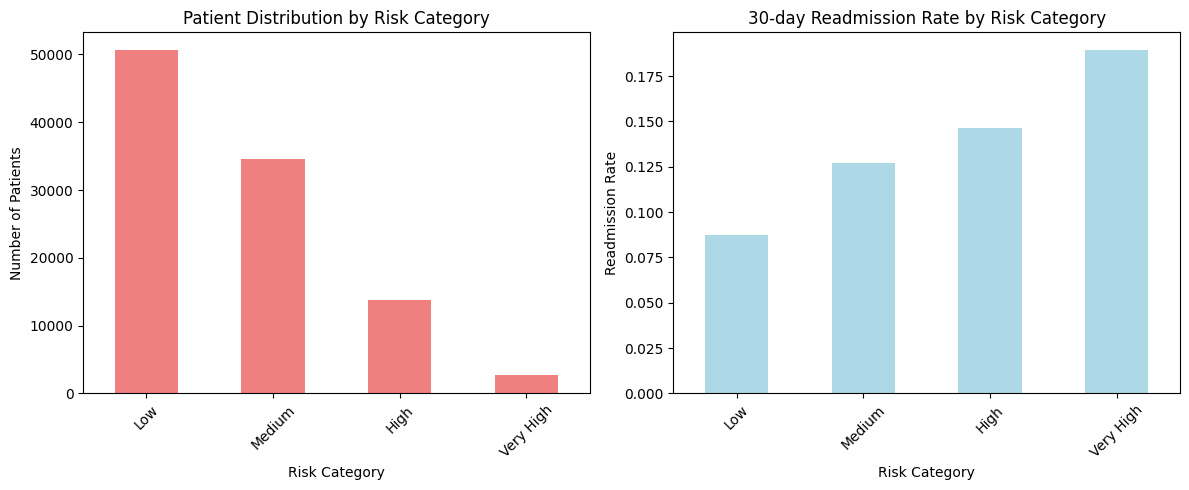

In [22]:
# Business impact and ROI estimation framework
print("=== ROI AND BUSINESS IMPACT ANALYSIS ===")

# Calculate baseline metrics for ROI estimation
total_patients = len(data)
readmissions_30day = data['readmitted_30day'].sum()
readmission_rate = data['readmitted_30day'].mean()

print(f"Baseline Metrics:")
print(f"- Total patients: {total_patients:,}")
print(f"- 30-day readmissions: {readmissions_30day:,}")
print(f"- 30-day readmission rate: {readmission_rate:.3f} ({readmission_rate*100:.1f}%)")

# Estimate potential impact of interventions
print(f"\n=== INTERVENTION IMPACT SCENARIOS ===")

# Scenario assumptions (these would be based on literature/hospital data)
avg_readmission_cost = 15000  # Example: $15,000 per readmission
intervention_cost_per_patient = 500  # Example: $500 per patient for intervention program

reduction_scenarios = [0.05, 0.10, 0.15, 0.20, 0.25]  # 5%, 10%, 15%, 20%, 25% reduction

print(f"\nROI Analysis (assuming ${avg_readmission_cost:,} per readmission, ${intervention_cost_per_patient:,} intervention cost):")
print("Scenario | Reduction | Prevented | Cost Savings | Intervention Cost | Net Savings | ROI")
print("-" * 90)

for reduction in reduction_scenarios:
    prevented_readmissions = readmissions_30day * reduction
    cost_savings = prevented_readmissions * avg_readmission_cost
    intervention_total_cost = total_patients * intervention_cost_per_patient
    net_savings = cost_savings - intervention_total_cost
    roi = (net_savings / intervention_total_cost) * 100
    
    print(f"{reduction:.0%}      | {reduction:.1%}     | {prevented_readmissions:.0f}       | ${cost_savings:,.0f}    | ${intervention_total_cost:,.0f}       | ${net_savings:,.0f}     | {roi:.1f}%")

# High-risk patient targeting analysis
print(f"\n=== HIGH-RISK PATIENT TARGETING ===")

# Create risk score based on key factors
risk_factors = []
weights = []

# Length of stay risk
if 'time_in_hospital' in data.columns:
    risk_factors.append((data['time_in_hospital'] > data['time_in_hospital'].quantile(0.75)).astype(int))
    weights.append(0.2)

# Prior utilization risk
if 'number_emergency' in data.columns:
    risk_factors.append((data['number_emergency'] > 0).astype(int))
    weights.append(0.15)

if 'number_inpatient' in data.columns:
    risk_factors.append((data['number_inpatient'] > data['number_inpatient'].quantile(0.75)).astype(int))
    weights.append(0.15)

# Medication complexity
if 'num_medications' in data.columns:
    risk_factors.append((data['num_medications'] > data['num_medications'].quantile(0.75)).astype(int))
    weights.append(0.15)

# Age risk (elderly patients)
age_risk = data['age'].isin(['[70-80)', '[80-90)', '[90-100)']).astype(int)
risk_factors.append(age_risk)
weights.append(0.1)

# Diabetes medication management
if 'diabetesMed' in data.columns:
    risk_factors.append((data['diabetesMed'] == 'Yes').astype(int))
    weights.append(0.1)

# A1C control
if 'A1Cresult' in data.columns:
    a1c_risk = data['A1Cresult'].isin(['>7', '>8']).astype(int)
    risk_factors.append(a1c_risk)
    weights.append(0.15)

# Calculate composite risk score
if risk_factors:
    data['risk_score'] = sum(factor * weight for factor, weight in zip(risk_factors, weights))
    
    # Create risk categories
    data['risk_category'] = pd.cut(data['risk_score'], 
                                  bins=[-0.01, 0.2, 0.4, 0.6, 1.0], 
                                  labels=['Low', 'Medium', 'High', 'Very High'])
    
    print("Risk Score Distribution:")
    risk_distribution = data['risk_category'].value_counts().sort_index()
    print(risk_distribution)
    
    print("\n30-day Readmission Rate by Risk Category:")
    risk_analysis = data.groupby('risk_category')['readmitted_30day'].agg(['count', 'mean']).round(3)
    risk_analysis.columns = ['Patient_Count', 'Readmission_Rate']
    print(risk_analysis)
    
    # Targeted intervention ROI
    print(f"\n=== TARGETED INTERVENTION ROI ===")
    high_risk_patients = data[data['risk_category'].isin(['High', 'Very High'])]
    high_risk_count = len(high_risk_patients)
    high_risk_readmissions = high_risk_patients['readmitted_30day'].sum()
    high_risk_rate = high_risk_patients['readmitted_30day'].mean()
    
    print(f"High-risk patients: {high_risk_count:,} ({high_risk_count/total_patients:.1%} of total)")
    print(f"High-risk readmissions: {high_risk_readmissions:,} ({high_risk_readmissions/readmissions_30day:.1%} of total)")
    print(f"High-risk readmission rate: {high_risk_rate:.3f} ({high_risk_rate*100:.1f}%)")
    
    print("\nTargeted Intervention ROI (High-risk patients only):")
    print("Scenario | Reduction | Prevented | Cost Savings | Intervention Cost | Net Savings | ROI")
    print("-" * 90)
    
    for reduction in reduction_scenarios:
        prevented_readmissions = high_risk_readmissions * reduction
        cost_savings = prevented_readmissions * avg_readmission_cost
        intervention_total_cost = high_risk_count * intervention_cost_per_patient
        net_savings = cost_savings - intervention_total_cost  
        roi = (net_savings / intervention_total_cost) * 100 if intervention_total_cost > 0 else 0
        
        print(f"{reduction:.0%}      | {reduction:.1%}     | {prevented_readmissions:.0f}       | ${cost_savings:,.0f}    | ${intervention_total_cost:,.0f}        | ${net_savings:,.0f}     | {roi:.1f}%")

    # Visualize risk distribution
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    risk_distribution.plot(kind='bar', color='lightcoral')
    plt.title('Patient Distribution by Risk Category')
    plt.xlabel('Risk Category')
    plt.ylabel('Number of Patients')
    plt.xticks(rotation=45)
    
    plt.subplot(1, 2, 2)
    risk_readmission_rates = data.groupby('risk_category')['readmitted_30day'].mean()
    risk_readmission_rates.plot(kind='bar', color='lightblue')
    plt.title('30-day Readmission Rate by Risk Category')
    plt.xlabel('Risk Category')
    plt.ylabel('Readmission Rate')
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()